C:\Users\yuli2\AppData\Local\Temp\ipykernel_13696\3371977181.py:7: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(r"C:\Users\yuli2\Desktop\5508最终\merged2025.csv")


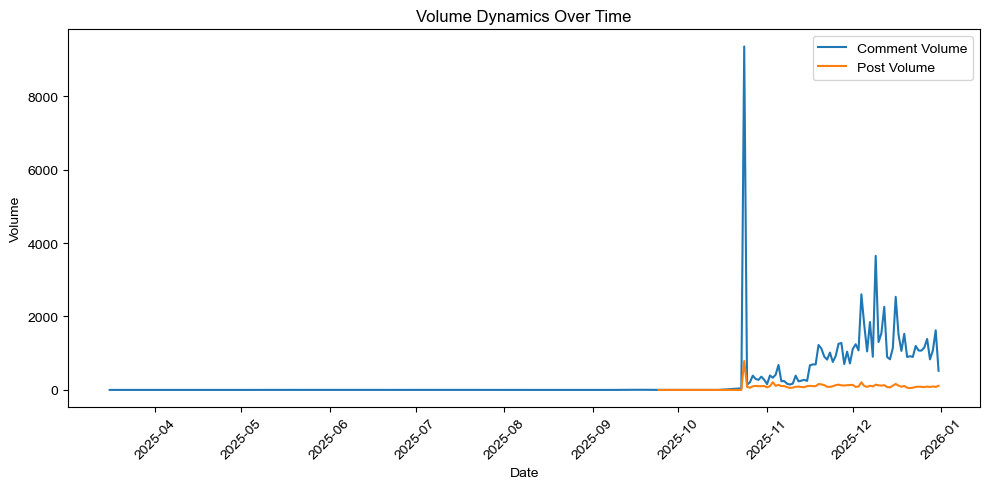

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

raw = pd.read_csv(r"C:\Users\yuli2\Desktop\5508最终\merged2025.csv")
raw.columns = raw.columns.str.strip()

# Time
raw['comment_time'] = pd.to_datetime(raw['post_time_x'], errors='coerce')
raw['post_time'] = pd.to_datetime(raw['post_time_y'], errors='coerce')

raw['date_comment'] = raw['comment_time'].dt.date
raw['date_post'] = raw['post_time'].dt.date

# Volume
comment_volume = raw.groupby('date_comment').size()
post_volume = raw.drop_duplicates('post_id').groupby('date_post').size()

# Plot
plt.figure(figsize=(10,5))
plt.plot(comment_volume.index, comment_volume.values, label='Comment Volume')
plt.plot(post_volume.index, post_volume.values, label='Post Volume')

plt.title("Volume Dynamics Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\yuli2\AppData\Local\Temp\ipykernel_13696\562005409.py:7: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(r"C:\Users\yuli2\Desktop\5508最终\merged2025.csv")
C:\Users\yuli2\AppData\Local\Temp\ipykernel_13696\562005409.py:8: DtypeWarning: Columns (2,6,26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sent = pd.read_csv(r"C:\Users\yuli2\Desktop\analyzed_cleaned1.csv")


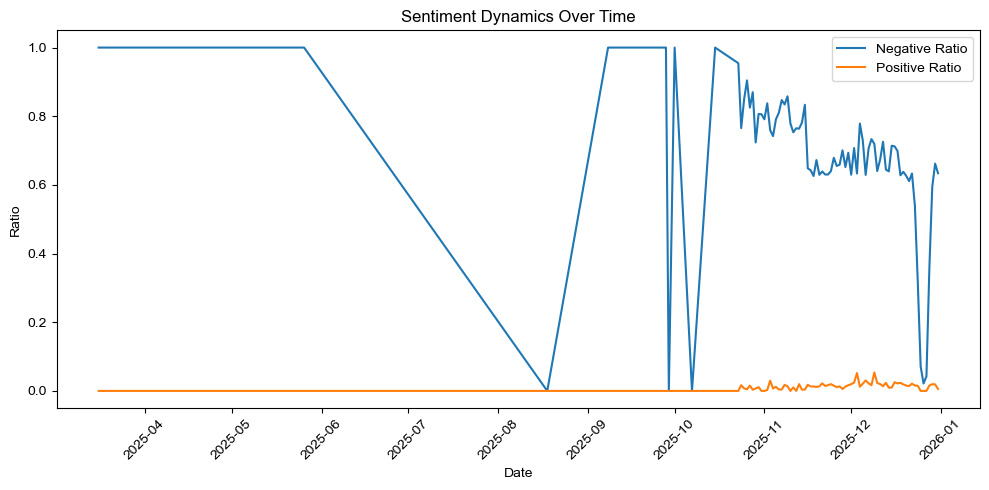

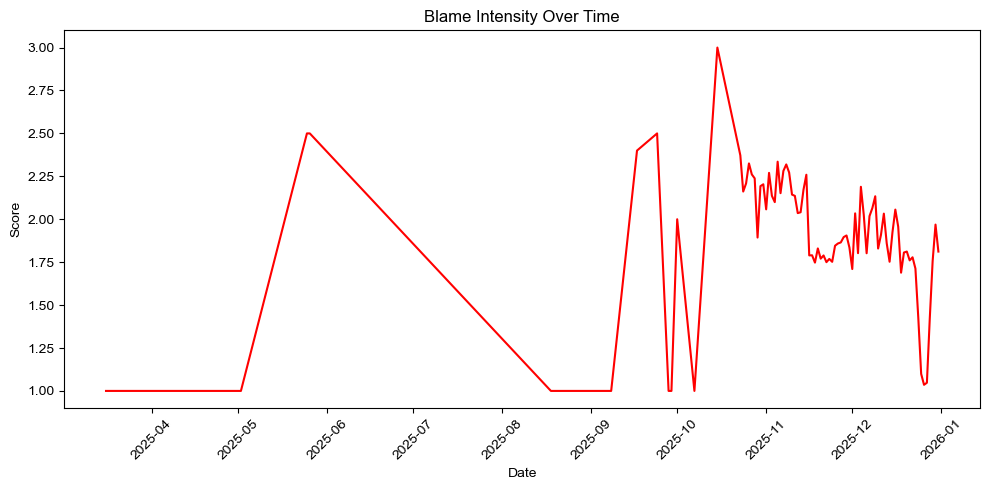

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

raw = pd.read_csv(r"C:\Users\yuli2\Desktop\5508最终\merged2025.csv")
df_sent = pd.read_csv(r"C:\Users\yuli2\Desktop\analyzed_cleaned1.csv")

raw.columns = raw.columns.str.strip()
df_sent.columns = df_sent.columns.str.strip()

# Time
raw['comment_time'] = pd.to_datetime(raw['post_time_x'], errors='coerce')
raw['date'] = raw['comment_time'].dt.date

# Merge
df = raw[['comment_id', 'date']].merge(
    df_sent[['comment_id', 'sentiment_category', 'blame_intensity']],
    on='comment_id',
    how='left'
)

# Blame mapping
mapping = {'weak':1, 'medium':2, 'strong':3}
df['blame_num'] = df['blame_intensity'].map(mapping)

# Sentiment ratio
sent_ratio = df.groupby(['date', 'sentiment_category']).size().unstack(fill_value=0)
sent_ratio = sent_ratio.div(sent_ratio.sum(axis=1), axis=0)

# Blame trend
blame_trend = df.groupby('date')['blame_num'].mean()

# Plot sentiment
plt.figure(figsize=(10,5))

if 'negative' in sent_ratio.columns:
    plt.plot(sent_ratio.index, sent_ratio['negative'], label='Negative Ratio')

if 'positive' in sent_ratio.columns:
    plt.plot(sent_ratio.index, sent_ratio['positive'], label='Positive Ratio')

plt.title("Sentiment Dynamics Over Time")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot blame
plt.figure(figsize=(10,5))
plt.plot(blame_trend.index, blame_trend.values, color='red')

plt.title("Blame Intensity Over Time")
plt.xlabel("Date")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\yuli2\AppData\Local\Temp\ipykernel_13696\1659468410.py:13: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(r"C:\Users\yuli2\Desktop\5508最终\merged2025.csv")


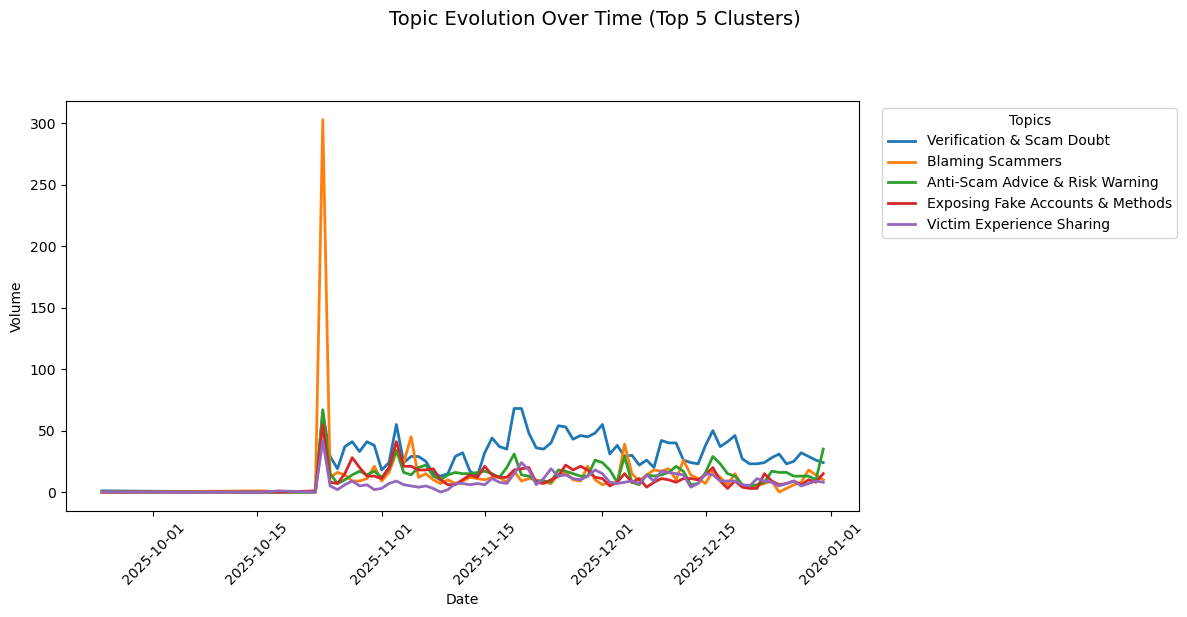

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0️⃣ Basic setting
# =========================
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 1️⃣ Load data
# =========================
raw = pd.read_csv(r"C:\Users\yuli2\Desktop\5508最终\merged2025.csv")
df_topic = pd.read_csv(r"C:\Users\yuli2\Desktop\topic_merged_final_all_comments.csv")

raw.columns = raw.columns.str.strip()
df_topic.columns = df_topic.columns.str.strip()

# =========================
# 2️⃣ English mapping (remove invalid class)
# =========================
label_map = {
    "质疑真实性/求证诈骗": "Verification & Scam Doubt",
    "防骗建议与风险提醒": "Anti-Scam Advice & Risk Warning",
    "分享个人受害经历": "Victim Experience Sharing",
    "检举曝光假账号/手法": "Exposing Fake Accounts & Methods",
    "求助维权/追款": "Seeking Help & Recovery",
    "指责骗子/诈骗集团": "Blaming Scammers",
    "嘲讽受害者/骗局荒谬": "Mocking Victims / Scam Ridicule",
    "呼吁严惩/制度改革": "Call for Punishment & Reform",
    "质疑社会/诈骗泛滥": "Social Critique on Scam Prevalence",
    "指责平台/监管失职": "Platform & Regulatory Failure Critique",
    "表达同情/家庭悲剧": "Empathy & Family Tragedy",
    "指责司法/法院轻纵": "Judicial Leniency Critique"
}

invalid_label = "缺少post文本/未参与post聚类"

# =========================
# 3️⃣ Time processing
# =========================
raw['post_time'] = pd.to_datetime(raw['post_time_y'], errors='coerce')
raw['date_post'] = raw['post_time'].dt.date

# =========================
# 4️⃣ Merge
# =========================
df = raw[['comment_id', 'post_id', 'date_post']].merge(
    df_topic[['comment_id', 'post_cluster_label']],
    on='comment_id',
    how='left'
)

# =========================
# 5️⃣ Clean + remove invalid + translate
# =========================
df = df.dropna(subset=['post_cluster_label', 'date_post'])
df = df[df['post_cluster_label'] != invalid_label]

df['post_cluster_label'] = df['post_cluster_label'].map(label_map)

# =========================
# 6️⃣ Deduplicate post level
# =========================
df_post = df.drop_duplicates('post_id')

# =========================
# 7️⃣ Pivot table
# =========================
topic_trend = df_post.pivot_table(
    index='date_post',
    columns='post_cluster_label',
    values='post_id',
    aggfunc='count',
    fill_value=0
)

# =========================
# 8️⃣ Top 5 topics
# =========================
top5 = topic_trend.sum().sort_values(ascending=False).head(5).index
topic_trend = topic_trend[top5].sort_index()

# =========================
# 9️⃣ Plot (100% stable title version)
# =========================
fig, ax = plt.subplots(figsize=(12, 6))

topic_trend.plot(ax=ax, linewidth=2)

fig.suptitle(
    "Topic Evolution Over Time (Top 5 Clusters)",
    fontsize=14,
    y=1.02
)

ax.set_xlabel("Date")
ax.set_ylabel("Volume")

ax.legend(title="Topics", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()